# Reproducing Bordi et al. 2013

This notebook walks through everything the article reports about its cohort of 70
relapsing-remitting patients and puts the number this package measures beside the number the
article prints. It draws Figures 2 to 4 from a record and from the bars digitised off the
paper, fits the two duration laws three ways each, tests the two qualitative claims the
article makes in prose, applies the barrier ratio of equation (7), calibrates the stochastic
model on the fitted means, and closes with the reproduction table, which fails the notebook
if any row falls outside its tolerance.

## Provenance of the data

**The records loaded below are synthetic.** The clinical series of the article was never
released: the paper carries no data availability statement, no supplementary material and no
deposited series. What ships with this package instead is a synthetic twin, 70 records
generated from the numbers the article prints. It is not the cohort of the study and no
clinical claim can be read off it.

To run the same notebook on a real cohort, replace the loading cell with

```python
weekly = msrelapse.read_weekly("my_cohort_weekly.csv")
durations = msrelapse.weekly_to_durations(weekly)
```

and leave every other cell as it is. The file has to obey the weekly schema of
`msrelapse.io`: one row per patient-week, with the columns `patient_id`, `week` and `state`,
the state being +1 in a relapse week and -1 in a remission week.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

import msrelapse
from msrelapse import plots

# Every random step of this notebook is drawn from this one seed.
SEED = 20130910
# Bootstrap replicates behind each of the four memorylessness tests. Their p
# value is (1 + exceeded) / (n_boot + 1), a Monte Carlo estimate that moves with
# the seed: over thirty seeds the p value of the cv test on the health durations
# spans about 0.57 to 0.92 at 200 replicates and about 0.72 to 0.83 at the 2000
# used here. The eight tests cost about two seconds at this setting.
N_BOOT = 2000

RELAPSE = msrelapse.PAPER.state_no_health.value
HEALTH = msrelapse.PAPER.state_health.value
STATE_NAMES = {RELAPSE: "flare", HEALTH: "health"}

pd.set_option("display.width", 100)
print(f"msrelapse {msrelapse.__version__}")

msrelapse 0.1.0


In [2]:
weekly = msrelapse.load_synthetic_bordi2013("weekly")
durations = msrelapse.load_synthetic_bordi2013("durations")

print(weekly.attrs["provenance"])
print(f"{weekly['patient_id'].nunique()} patients over {len(weekly)} patient-weeks")
weekly.head()

These files hold synthetic data, not the clinical series of Bordi et al. 2013.
70 patients over 28302 patient-weeks


,patient_id,week,state
0,p0001,0,1
1,p0001,1,1
2,p0001,2,-1
3,p0001,3,-1
4,p0001,4,-1


In [3]:
print(msrelapse.provenance())

These files hold synthetic data, not the clinical series of Bordi et al. 2013.
No clinical claim may be read off them. That first sentence stands on the first
line by itself because msrelapse.datasets copies that line, and only that line,
onto every frame it hands out.

What they are
Seventy simulated relapsing-remitting records, in the three schemas of
msrelapse.io: synthetic_bordi2013_weekly.csv (one row per patient-week),
synthetic_bordi2013_durations.csv (the run length encoding of the same records)
and synthetic_bordi2013_events.csv (one row per relapse). The three describe the
same records and convert into one another, with the caveat that the events to
weekly direction applies the rounding rule of the study and is lossy.

None of the three carries a provenance column: msrelapse.io fixes the columns
of each schema and validates a frame against them, so an extra column would
fail the check the loader runs. The provenance travels instead as this file, as
the first line of it on fra

## Figures 2 to 4

Figures 3 and 4 are drawn twice: on the left the bars digitised from the article, on the
right the same figure measured on this record. Figure 2 is drawn once, from this record,
because the article prints no numbers for its three series. It shows the three patients of
this cohort with the most relapses, which is the counterpart of the three sample patients of
the paper.

In [4]:
relapse_runs = durations[durations["state"] == RELAPSE]
per_patient_relapses = relapse_runs.groupby("patient_id", sort=True).size()
# The counts are already in patient id order and the sort below is stable, so a
# tie is broken by the patient id and these three names never move.
examples = list(per_patient_relapses.sort_values(ascending=False, kind="stable").head(3).index)
print(per_patient_relapses[examples])

patient_id
p0068    12
p0007    10
p0047    10
dtype: int64


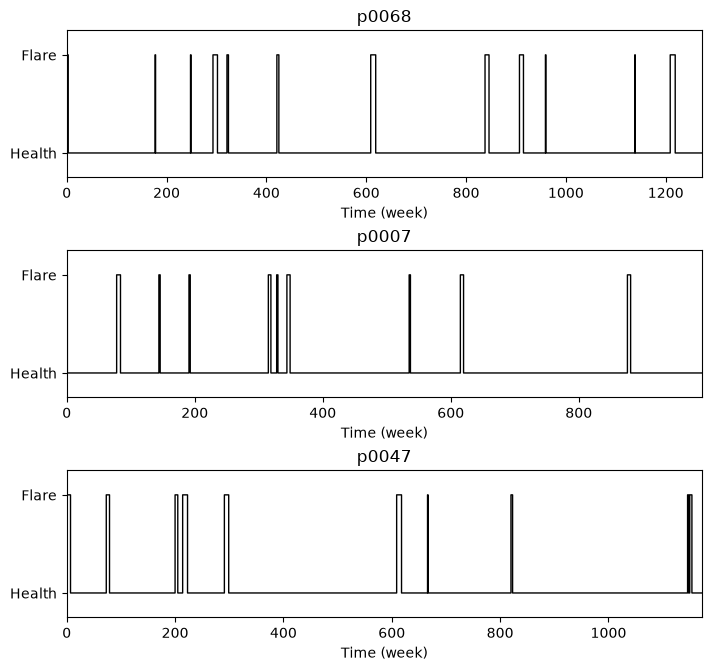

In [5]:
plots.fig2_sample_patients(weekly, examples)
plt.show()

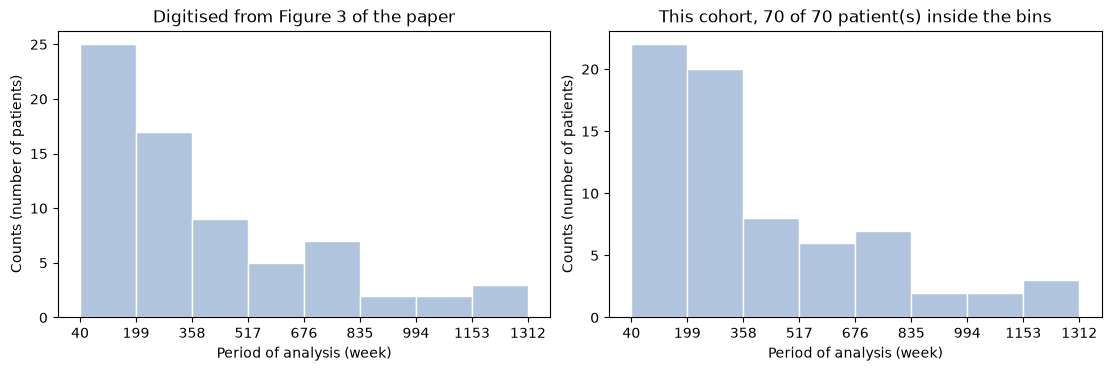

In [6]:
followup_weeks = weekly.groupby("patient_id", sort=True).size()
axes = plt.subplots(1, 2, figsize=(11.0, 3.6), layout="constrained")[1]
plots.fig3_rr_phase_histogram(ax=axes[0])
plots.fig3_rr_phase_histogram(followup_weeks.to_numpy(), ax=axes[1])
plt.show()

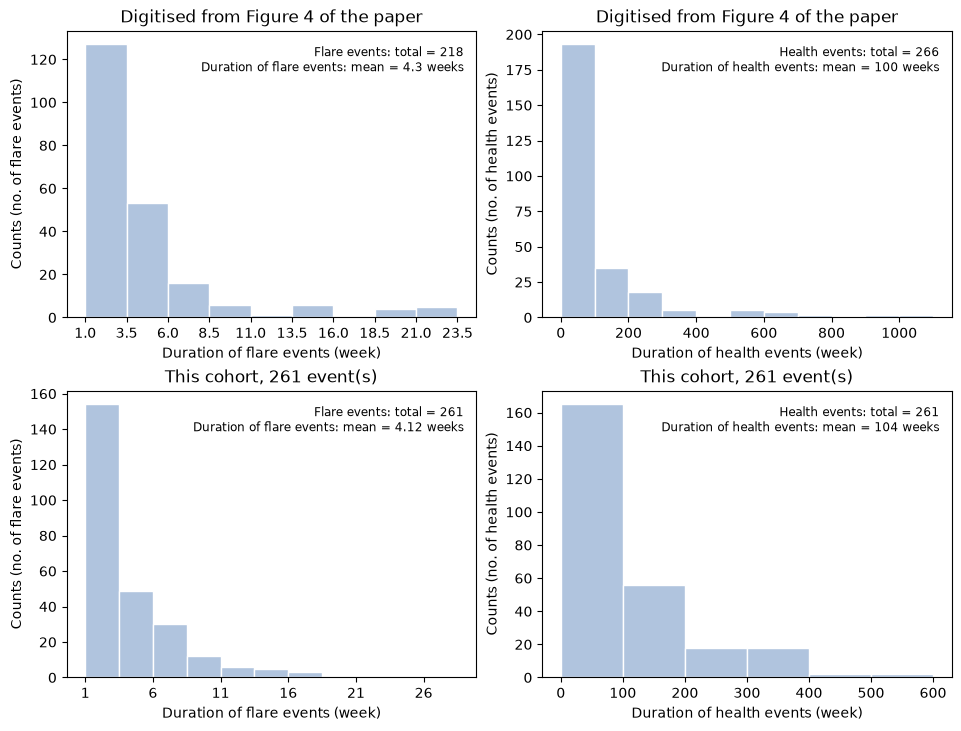

In [7]:
axes = plt.subplots(2, 2, figsize=(9.5, 7.2), layout="constrained")[1]
plots.fig4_duration_histograms(axes=axes[0])
plots.fig4_duration_histograms(durations, axes=axes[1])
plt.show()

## The two mean durations, fitted three ways

The article reports one mean per state and no interval. The naive fit is its arithmetic:
every recorded run counted as complete, the final remission of a record included although the
end of follow up cut it short. The censored fit gives that run its time but not its event,
which is the estimate of the process behind the record. The geometric fit reads the same runs
as whole weeks, which is what a weekly record holds, and it returns the same mean as the
censored exponential; the two differ in what they claim about the days between the integers,
not in what they estimate.

The last column is the log likelihood at the fitted parameter, and it is what separates rows
that agree in every other column. Read it down one family only: the two exponential fits
differ by what the censored runs contribute, while the geometric number is the probability of
a whole week rather than a density, so it does not sit on the same scale as the two above it.
The two relapse rows that stay identical are identical for a reason the table gives itself:
no relapse run of this record is censored, so the naive and the censored exponential fits are
one fit.

In [8]:
fit_rows = []
for state in (RELAPSE, HEALTH):
    fits = {
        "naive": msrelapse.fit_durations(durations, state, censoring=False),
        "censored": msrelapse.fit_durations(durations, state),
        "geometric": msrelapse.fit_durations(durations, state, family="geometric"),
    }
    for label, fit in fits.items():
        fit_rows.append(
            (
                STATE_NAMES[state],
                label,
                fit.n,
                fit.n_censored,
                fit.mean,
                fit.ci_low,
                fit.ci_high,
                fit.loglik,
            )
        )

duration_fits = pd.DataFrame(
    fit_rows,
    columns=["state", "fit", "n", "n_censored", "mean_w", "ci_low", "ci_high", "loglik"],
)
duration_fits

,state,fit,n,n_censored,mean_w,ci_low,ci_high,loglik
0,flare,naive,261,0,4.118774,3.648211,4.650033,-630.459994
1,flare,censored,261,0,4.118774,3.648211,4.650033,-630.459994
2,flare,geometric,261,0,4.118774,3.706124,4.577369,-595.846072
3,health,naive,261,0,104.318008,92.399843,117.773434,-1473.982884
4,health,censored,261,70,142.549738,123.701693,164.269602,-1138.300977
5,health,geometric,261,70,142.549738,123.763350,164.187766,-1137.629463


## Is the record memoryless, and does it carry a period?

The article asserts both claims on the shape of two histograms. The four tests below give the
memorylessness of each state a number, the figure under them puts the observed survival of
each state beside the exponential fitted to it, and the Fisher g test after that reads the
rhythm of the relapse onsets. A large p value means the record does not contradict the
article, and not that the claim is established: none of these tests has much power on a cohort
of this size, and the periodicity test has almost none at four onsets per patient.

All four tests read their p value off a bootstrap, so every one of those numbers carries a
Monte Carlo error of its own on top of the sampling error of the cohort, and the table shows
them to three decimals for that reason.

In [9]:
memoryless_rows = []
# The Kolmogorov-Smirnov reading of each state is kept, because the closing
# table reports it too and is handed these tests rather than drawing a second
# bootstrap of its own.
ks_tests = {}
for state in (RELAPSE, HEALTH):
    for method in ("hazard", "cv", "ks", "ad"):
        test = msrelapse.test_memoryless(durations, state, method=method, n_boot=N_BOOT, rng=SEED)
        memoryless_rows.append((STATE_NAMES[state], method, test.n, test.statistic, test.p_value))
        if method == "ks":
            ks_tests[state] = test

memoryless = pd.DataFrame(
    memoryless_rows,
    columns=["state", "method", "n", "statistic", "p_value"],
)
# Three decimals, which is as far as a bootstrap of this size can be read.
memoryless["p_value"] = memoryless["p_value"].round(3)
memoryless

,state,method,n,statistic,p_value
0,flare,hazard,261,0.506999,0.685
1,flare,cv,261,0.936376,0.172
2,flare,ks,261,0.215564,0.516
3,flare,ad,261,8.760917,0.716
4,health,hazard,191,1.484009,0.197
5,health,cv,191,1.009505,0.747
6,health,ks,191,0.044204,0.713
7,health,ad,191,0.363492,0.749


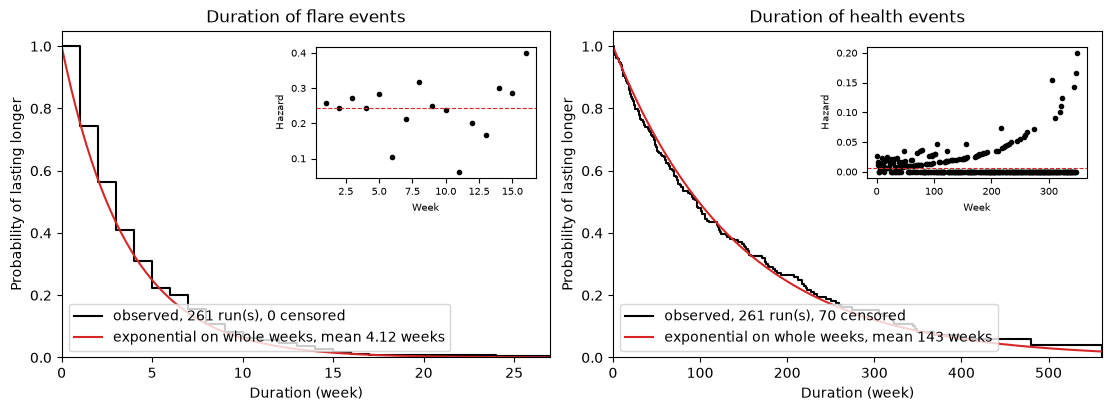

In [10]:
axes = plt.subplots(1, 2, figsize=(11.0, 4.0), layout="constrained")[1]
plots.fig_survival_vs_exponential(durations, RELAPSE, ax=axes[0])
plots.fig_survival_vs_exponential(durations, HEALTH, ax=axes[1])
plt.show()

In [11]:
periodicity = msrelapse.test_periodicity(weekly, method="fisher_g")
print(periodicity.pooled)
print(periodicity.pooled.details)
periodicity.per_patient[["n_weeks", "n_onsets", "p_value"]].describe()

TestResult(method='fisher_combined:fisher_g', n=41, statistic=11.4899, p_value=1; Bordi, Umeton et al., Int J Genomics 2013, doi:10.1155/2013/910321)
{'n_patients': 70.0, 'n_skipped_short': 0.0, 'n_skipped_few_onsets': 29.0, 'n_skipped_flat_spectrum': 0.0}


,n_weeks,n_onsets,p_value
count,70.000000,70.000000,41.000000
mean,404.314286,3.728571,0.901030
std,314.575838,2.637090,0.192544
min,48.000000,1.000000,0.242863
25%,154.000000,1.000000,0.880056
50%,312.500000,4.000000,1.000000
75%,580.500000,5.000000,1.000000
max,1272.000000,12.000000,1.000000


## The barrier ratio of equation (7)

Equation (7) reads the ratio of the two barriers off the two mean durations. The means are
the naive ones, because those are the means the article used to reach its 3.1. The table of
the three sample patients puts each printed value beside the value its neighbours imply: the
two lower rows agree to two decimals, while patient 23 does not. The asymmetry its two
printed durations ask for is about 0.256, and the 0.25 printed beside them delivers a ratio
of about 10.8 rather than the 11.8 printed with it. That is an inconsistency in the article
itself, confirmed against its own Figure 8(a), and not a transcription error here.

In [12]:
cohort_ratio = msrelapse.barrier_ratio(durations)
printed_ratio = msrelapse.barrier_ratio_from_durations(
    msrelapse.PAPER.tau_health_cohort_weeks.value,
    msrelapse.PAPER.tau_no_health_cohort_weeks.value,
)
print(f"this record: {cohort_ratio:.3f}")
print(f"the durations the article prints: {printed_ratio:.3f}")
print(f"the ratio the article prints: {msrelapse.PAPER.barrier_ratio_cohort.value}")

this record: 3.283
the durations the article prints: 3.157
the ratio the article prints: 3.1


In [13]:
patient_params = msrelapse.per_patient_params(durations)
patient_params[patient_params["patient_id"].isin(examples)]

,patient_id,n_relapses,n_remissions,tau_health,tau_relapse,barrier_ratio,beta
6,p0007,10,10,95.800000,3.400000,3.728023,0.155301
46,p0047,10,10,111.800000,5.400000,2.796913,0.124064
67,p0068,12,12,101.083333,4.916667,2.898315,0.128047


In [14]:
msrelapse.paper_patients()

,patient_id,tau_health,tau_relapse,barrier_ratio_printed,beta_printed,barrier_ratio_from_taus,beta_from_ratio,barrier_ratio_from_beta_printed
0,23,117.7,1.5,11.8,0.25,11.759678,0.256261,10.774553
1,32,54.0,2.1,5.3,0.19,5.376443,0.191838,5.273121
2,53,47.0,4.3,2.7,0.12,2.639591,0.117529,2.697795


## Calibrating the stochastic model on the fitted means

The calibration searches for the asymmetry and the noise whose exact mean first passage
times, from the bottom of each well to the saddle, are the two fitted means. The noise it
asks for is about twice the only noise value the article prints, which is the gap
`docs/paper_facts.md` records: the article's own epsilon does not reproduce its own durations
under an exact first passage reading.

In [15]:
tau_health = msrelapse.fit_durations(durations, HEALTH).mean
tau_relapse = msrelapse.fit_durations(durations, RELAPSE).mean
beta, sigma = msrelapse.calibrate(tau_health, tau_relapse, passage="bottom_to_saddle")
well = msrelapse.DoubleWell(msrelapse.PAPER.alpha_reference.value, beta)

print(f"fitted means: {tau_health:.1f} weeks in health, {tau_relapse:.2f} weeks in flare")
print(f"beta {beta:.4f}, sigma {sigma:.4f}, so epsilon = sigma^2 is {sigma**2:.4f}")
print(f"the article prints epsilon = {msrelapse.PAPER.epsilon_noise_variance.value}")
print(well.barriers())

fitted means: 142.5 weeks in health, 4.12 weeks in flare
beta 0.2251, sigma 0.4947, so epsilon = sigma^2 is 0.2447
the article prints epsilon = 0.13
Barriers(health=0.5126061255500624, relapse=0.06553505130240371)


The two figures below are the article's Figures 6 and 7 redrawn at the asymmetry and the
noise the calibration just returned, not at the printed beta = 0.08 and epsilon = 0.13; every
panel is labelled with the values it was drawn at. The version at the printed parameters is
what `msrelapse reproduce` writes, and it is what the defaults of both plotting functions
give.

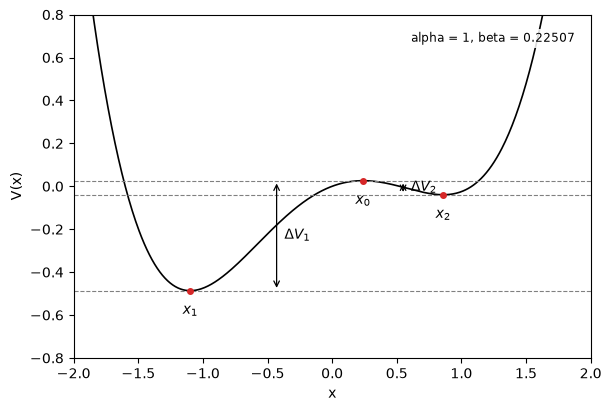

In [16]:
plots.fig6_asymmetric_potential(beta=beta)
plt.show()

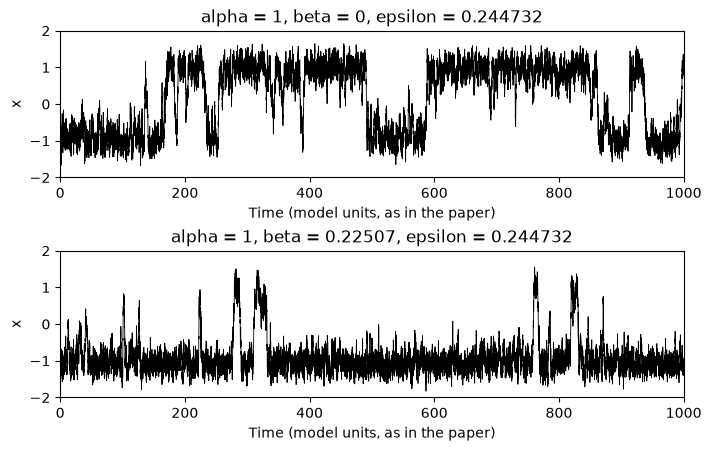

In [17]:
plots.fig7_simulated_paths(
    sigma=sigma,
    betas=(msrelapse.PAPER.beta_symmetric.value, beta),
    rng=SEED,
)
plt.show()

## The potential of each example patient, Figure 8

The article fits a patient by fixing alpha at its reference value and moving the asymmetry
until the two wells stand in the ratio equation (7) reads off that patient's durations. The
three panels below are that fit for the three patients of Figure 2 above.

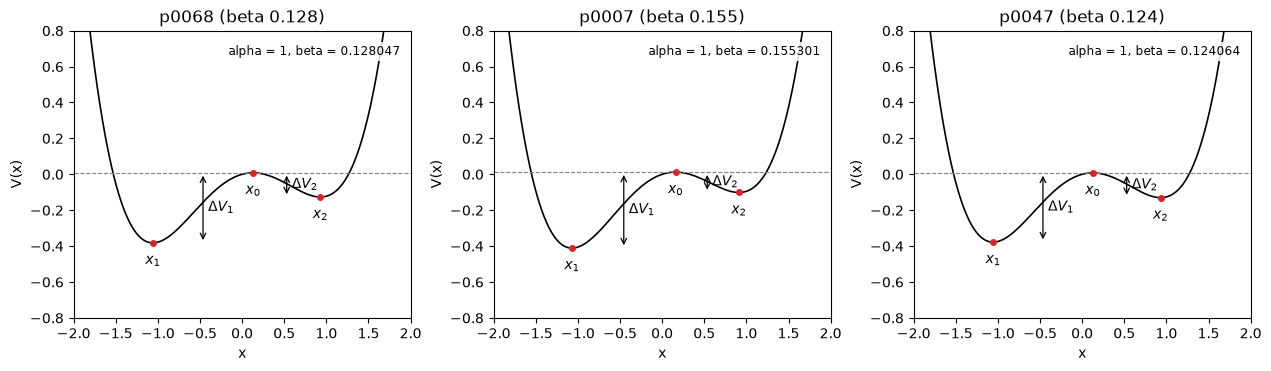

In [18]:
example_betas = patient_params.set_index("patient_id").loc[examples, "beta"]
labels = [f"{patient} (beta {value:.3f})" for patient, value in example_betas.items()]
plots.fig8_patient_potentials(list(example_betas), labels)
plt.show()

## The closing table

Every aggregate the article reports, measured on this record the way the article measured its
own, with the rule each comparison is judged under. The two goodness of fit rows and the
periodicity row are the tests measured above, handed to the table rather than drawn again, so
that each of those p values appears once in this notebook. The cell after the table raises if
any judged row falls outside its tolerance, so that a failed reproduction fails the notebook.

In [19]:
table = msrelapse.reproduction_table(
    weekly,
    rng=SEED,
    ks_tests=ks_tests,
    periodicity=periodicity,
)
table

,quantity,paper,reproduced,tolerance,within_tolerance
0,mean relapse duration (weeks),4.3,4.118774,5% of the printed value,True
1,mean remission duration (weeks),100.0,104.318008,10% of the printed value,True
2,relapse duration range (weeks),"(1.0, 24.0)","(1.0, 27.0)",shortest at least 1 and longest at most 30 weeks,True
3,longest remission (weeks),1000.0,561.0,"between 0.1 and 3 times the printed value, an ...",True
4,relapsing-remitting phase range (weeks),"(40.0, 1311.0)","(48.0, 1272.0)","inside 40 to 1312 weeks by inclusion, the prin...",True
5,"barrier ratio dV1/dV2, equation (7)",3.1,3.283124,"within 0.2 of 3.157, the value the printed dur...",True
6,"exponential fit, relapse durations (KS p value)",None,0.515742,"above alpha = 0.05, so that the durations are ...",True
7,"exponential fit, remission durations (KS p value)",None,0.712644,"above alpha = 0.05, so that the durations are ...",True
8,periodicity of the relapse onsets (pooled Fish...,None,1.0,"pooled p above alpha = 0.05, so that no period...",True


In [20]:
judged = table[table["within_tolerance"].notna()]
outside = judged[~judged["within_tolerance"].astype(bool)]
if not outside.empty:
    raise AssertionError(
        f"{len(outside)} row(s) of the closing table fall outside tolerance:\n{table.to_string()}"
    )
print(f"within_tolerance: True on every one of the {len(judged)} judged rows")

within_tolerance: True on every one of the 9 judged rows


## How to cite

This notebook reproduces the article below, and the package it uses carries the same
reference on every result object. The text is what `msrelapse.citation()` prints.

```text
Bordi I, Umeton R, Ricigliano VAG, Annibali V, Mechelli R, Ristori G, Grassi F, Salvetti M, Sutera A. A mechanistic, stochastic model helps understand multiple sclerosis course and pathogenesis. International Journal of Genomics. 2013;2013:910321. doi:10.1155/2013/910321.

@article{bordi2013mechanistic,
  author    = {Bordi, Isabella and Umeton, Renato and Ricigliano, Vito A. G. and Annibali, Viviana and Mechelli, Rosella and Ristori, Giovanni and Grassi, Francesca and Salvetti, Marco and Sutera, Alfonso},
  title     = {A mechanistic, stochastic model helps understand multiple sclerosis course and pathogenesis},
  journal   = {International Journal of Genomics},
  volume    = {2013},
  pages     = {910321},
  year      = {2013},
  doi       = {10.1155/2013/910321},
  publisher = {Wiley}
}

% The DOI below is a placeholder: the archive DOI is minted at the first release.
@software{msrelapse,
  author  = {Umeton, Renato},
  title   = {msrelapse: a reference implementation of the Bordi et al. 2013 double well model of multiple sclerosis},
  year    = {2026},
  version = {0.1.0},
  url     = {https://github.com/renato-umeton/multiple-sclerosis-modeling-bordi},
  doi     = {10.5281/zenodo.XXXXXXX}
}
```